In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data=load_breast_cancer()

x=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target,name='target')

In [2]:
print("x_shape : "+str(x.shape))
print("y_shape : "+str(y.shape))

x_shape : (569, 30)
y_shape : (569,)


In [3]:
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
print(data.target_names)
print(y.value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [5]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
x.isnull().sum().sum()

np.int64(0)

In [7]:
x.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [8]:
x.duplicated().sum()

np.int64(0)

In [9]:
df=x.copy()
df['target']=y

df.groupby('target').mean().T

target,0,1
mean radius,17.462830,12.146524
mean texture,21.604906,17.914762
mean perimeter,115.365377,78.075406
mean area,978.376415,462.790196
mean smoothness,0.102898,0.092478
mean compactness,0.145188,0.080085
mean concavity,0.160775,0.046058
mean concave points,0.087990,0.025717
mean symmetry,0.192909,0.174186
mean fractal dimension,0.062680,0.062867


In [10]:
Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((x < lower_bound) | (x > upper_bound))

outlier_count = outliers.sum().sort_values(ascending=False)

outlier_count

,0
area error,65
radius error,38
perimeter error,38
worst area,35
smoothness error,30
fractal dimension error,28
compactness error,28
symmetry error,27
mean area,25
worst fractal dimension,24


In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [12]:
print(x_train.shape)
print(x_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(455, 30)
(114, 30)
target
1    285
0    170
Name: count, dtype: int64
target
1    72
0    42
Name: count, dtype: int64


In [13]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [14]:
print("Train mean:", x_train_scaled.mean())
print("Train std:", x_train_scaled.std())

Train mean: -1.145197083276352e-16
Train std: 1.0


In [15]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(x_train_scaled, y_train)

LogisticRegression(random_state=42)

In [16]:
y_pred = logistic_model.predict(x_test_scaled)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[41  1]
 [ 1 71]]


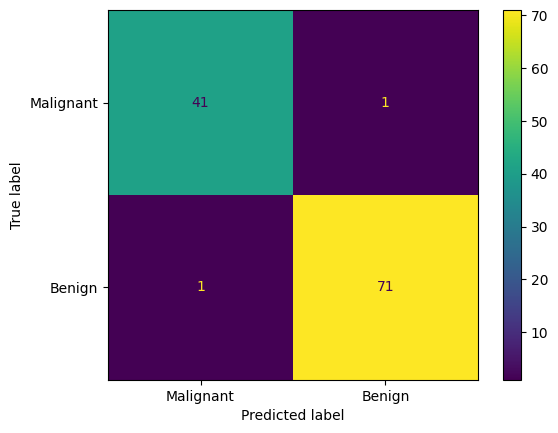

In [18]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot()
plt.show()

In [19]:
malignant_recall = recall_score(
    y_test,
    y_pred,
    pos_label=0
)

print("Malignant Recall:", malignant_recall)

Malignant Recall: 0.9761904761904762


In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Malignant", "Benign"]
    )
)

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [21]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)

svm_model.fit(x_train_scaled, y_train)

SVC(random_state=42)

In [22]:
y_pred_svm = svm_model.predict(x_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy:", accuracy_svm)


from sklearn.metrics import classification_report
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["Malignant", "Benign"]
    )
)

Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [23]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [24]:
y_pred_tree = tree_model.predict(x_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
print("Accuracy:", accuracy_tree)

print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["Malignant", "Benign"]
    )
)

Accuracy: 0.9122807017543859
              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [25]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(x_train_scaled, y_train)

GaussianNB()

In [26]:
y_pred_nb = nb_model.predict(x_test_scaled)

from sklearn.metrics import classification_report, accuracy_score

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Accuracy:", accuracy_nb)

print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["Malignant", "Benign"]
    )
)

Accuracy: 0.9298245614035088
              precision    recall  f1-score   support

   Malignant       0.90      0.90      0.90        42
      Benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [37]:
y_pred_knn = knn_model.predict(x_test_scaled)

from sklearn.metrics import classification_report, accuracy_score

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", accuracy_knn)

print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=["Malignant", "Benign"]
    )
)

Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

   Malignant       1.00      0.95      0.98        42
      Benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [30]:
y_pred_rf = rf_model.predict(x_test)

from sklearn.metrics import classification_report, accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Malignant", "Benign"]
    )
)

Accuracy: 0.956140350877193
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [34]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ("logistic", LogisticRegression(random_state=42)),
        ("svm", SVC(probability=True, random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=3))
    ],
    voting="soft"
)

voting_model.fit(x_train_scaled, y_train)

VotingClassifier(estimators=[('logistic', LogisticRegression(random_state=42)),
                             ('svm', SVC(probability=True, random_state=42)),
                             ('knn', KNeighborsClassifier(n_neighbors=3))],
                 voting='soft')

In [35]:
y_pred_voting = voting_model.predict(x_test_scaled)

print(
    classification_report(
        y_test,
        y_pred_voting,
        target_names=["Malignant", "Benign"]
    )
)

print("Accuracy:", accuracy_score(y_test, y_pred_voting))

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Accuracy: 0.9824561403508771


In [47]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=200,
    random_state=42
)

bagging_model.fit(x_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=200, random_state=42)

In [48]:
y_pred_bagging = bagging_model.predict(x_test)

print(
    classification_report(
        y_test,
        y_pred_bagging,
        target_names=["Malignant", "Benign"]
    )
)

print("Accuracy:", accuracy_score(y_test, y_pred_bagging))

              precision    recall  f1-score   support

   Malignant       0.93      0.93      0.93        42
      Benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Accuracy: 0.9473684210526315


In [50]:
from sklearn.ensemble import GradientBoostingClassifier

boosting_model = GradientBoostingClassifier(
    random_state=42
)

boosting_model.fit(x_train, y_train)

GradientBoostingClassifier(random_state=42)

In [52]:
y_pred_boosting = boosting_model.predict(x_test)

In [54]:
print(
    classification_report(
        y_test,
        y_pred_boosting,
        target_names=["Malignant", "Benign"]
    )
)

print("Accuracy:", accuracy_score(y_test, y_pred_boosting))

              precision    recall  f1-score   support

   Malignant       0.97      0.90      0.94        42
      Benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Accuracy: 0.956140350877193


In [56]:
from sklearn.ensemble import StackingClassifier

stacking_model = StackingClassifier(
    estimators=[
        ("logistic", LogisticRegression(random_state=42)),
        ("svm", SVC(probability=True, random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=3))
    ],
    final_estimator=LogisticRegression(random_state=42)
)

stacking_model.fit(x_train_scaled, y_train)

StackingClassifier(estimators=[('logistic',
                                LogisticRegression(random_state=42)),
                               ('svm', SVC(probability=True, random_state=42)),
                               ('knn', KNeighborsClassifier(n_neighbors=3))],
                   final_estimator=LogisticRegression(random_state=42))

In [58]:
y_pred_stacking = stacking_model.predict(x_test_scaled)

print(
    classification_report(
        y_test,
        y_pred_stacking,
        target_names=["Malignant", "Benign"]
    )
)
print("Accuracy:", accuracy_score(y_test, y_pred_stacking))

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Accuracy: 0.9824561403508771
